In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

In [21]:
df_tain = pd.read_csv(r"../data/cleaned/train.csv")
df_test = pd.read_csv(r"../data/cleaned/test.csv")
df_val= pd.read_csv(r"../data/cleaned/val.csv")

In [22]:
df_test

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,9606,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg
1,5661,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg
2,9355,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg
3,7757,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg
4,2284,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg
...,...,...,...,...,...,...,...,...,...
1498,4063,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg
1499,9437,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg
1500,6604,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg
1501,5841,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg


In [23]:
#encoding the label
label_encode = LabelEncoder()
df_tain["dx_encode"] = label_encode.fit_transform(df_tain["dx"])

In [24]:
df_test["dx_encode"] = label_encode.fit_transform(df_test["dx"])

df_val["dx_encode"] = label_encode.fit_transform(df_val["dx"])

In [25]:
df_val[["dx","dx_encode"]]

,dx,dx_encode
0,nv,5
1,nv,5
2,nv,5
3,nv,5
4,nv,5
...,...,...
1498,nv,5
1499,bkl,2
1500,mel,4
1501,bkl,2


In [64]:
df_tain

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,8561,HAM_0007001,ISIC_0026573,nv,histo,60.0,female,lower extremity,../data/all_image/ISIC_0026573.jpg,5
1,6583,HAM_0006055,ISIC_0031456,nv,follow_up,75.0,female,lower extremity,../data/all_image/ISIC_0031456.jpg,5
2,5171,HAM_0006068,ISIC_0024591,nv,follow_up,35.0,male,back,../data/all_image/ISIC_0024591.jpg,5
3,3248,HAM_0001590,ISIC_0025722,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0025722.jpg,5
4,7903,HAM_0002015,ISIC_0034035,nv,histo,30.0,female,lower extremity,../data/all_image/ISIC_0034035.jpg,5
...,...,...,...,...,...,...,...,...,...,...
7004,7810,HAM_0000639,ISIC_0025257,nv,histo,70.0,female,upper extremity,../data/all_image/ISIC_0025257.jpg,5
7005,853,HAM_0007043,ISIC_0029947,bkl,consensus,75.0,male,face,../data/all_image/ISIC_0029947.jpg,2
7006,4257,HAM_0001568,ISIC_0030614,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0030614.jpg,5
7007,3382,HAM_0005800,ISIC_0028864,nv,follow_up,40.0,female,upper extremity,../data/all_image/ISIC_0028864.jpg,5


In [26]:
#data preprocessing pipe line 
# 1 we have test train and validate date set 
# we gonna perfrom agumentation only for the train cuz agumentation used to make the model undertsand the data easily nothing much
# for this we wanna convert the pd to tensor flow data set 
#and then convert images to array 
# for model tained we only need 

In [27]:
img_size = (256,256)
batch_size = 32

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(factor=0.15, value_range=(0.0, 1.0)),
    tf.keras.layers.RandomCrop(224,224)
])

In [29]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [30]:
def preprocess_train(image_path, label):
    image, label = preprocess_image(image_path, label)
    image = data_augmentation(image)
    return image, label

In [31]:
def preprocess_test(image_path, label):
    image, label = preprocess_image(image_path, label)
    return image, label

In [32]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_tain["path"].values,
        df_tain["dx_encode"].values
    )
)

train_dataset = (
    train_dataset
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [33]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_val["path"].values,
        df_val["dx_encode"].values
    )
)

val_dataset = (
    val_dataset
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)


In [34]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_test["path"].values,
        df_test["dx_encode"].values
    )
)

test_dataset = (
    test_dataset
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [35]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [36]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels:", labels.numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Labels: [5 2 1 5 2 5 0 0 4 2 0 5 5 1 5 5 2 4 4 2 1 5 5 5 5 5 2 5 5 5 5 5]


In [37]:
for images , label in train_dataset.take(1):
    print(images)
    print(label)

tf.Tensor(
[[[[0.4439013  0.40522975 0.43622476]
   [0.44566095 0.40218014 0.43734628]
   [0.44464427 0.39385486 0.4301566 ]
   ...
   [0.39000034 0.32488906 0.33548814]
   [0.38781708 0.32798272 0.34939164]
   [0.39026642 0.32551295 0.35646278]]

  [[0.44827986 0.40526748 0.43911058]
   [0.4502896  0.40555942 0.4389696 ]
   [0.44867343 0.3963794  0.43084604]
   ...
   [0.3948673  0.32577553 0.33916926]
   [0.38726515 0.3267807  0.34705964]
   [0.38559526 0.32238623 0.35076833]]

  [[0.45084673 0.40863538 0.44615263]
   [0.45251375 0.41135812 0.44329965]
   [0.44653416 0.40278697 0.43055952]
   ...
   [0.39362556 0.3251473  0.33799282]
   [0.3872701  0.32260692 0.33297333]
   [0.38823396 0.32057896 0.3321306 ]]

  ...

  [[0.4120654  0.3619901  0.40493357]
   [0.41673088 0.3616531  0.40624762]
   [0.41868275 0.35962105 0.4055516 ]
   ...
   [0.47305357 0.406008   0.4208433 ]
   [0.46916413 0.4077378  0.43079263]
   [0.4643743  0.41776168 0.44119763]]

  [[0.41062826 0.36405677 0.402460

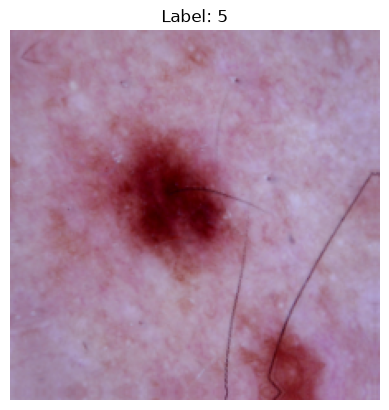

In [38]:
for image, label in train_dataset.take(1):
    plt.imshow(image[0].numpy())
    plt.title(f"Label: {label[0].numpy()}")
    plt.axis("off")
    plt.show()

In [ ]:
#class weight balence

In [42]:
y_train = df_tain["dx_encode"].values


class_weights = compute_class_weight(class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)

# Convert to dictionary
class_weight_dict = dict(enumerate(class_weights))

class_weight_dict

{0: np.float64(4.372426699937617),
 1: np.float64(2.7813492063492062),
 2: np.float64(1.3020620471855842),
 3: np.float64(12.51607142857143),
 4: np.float64(1.2853475151292866),
 5: np.float64(0.2133572798392743),
 6: np.float64(10.113997113997113)}

In [ ]:
#EDA data visulaization

In [ ]:
#class distribution

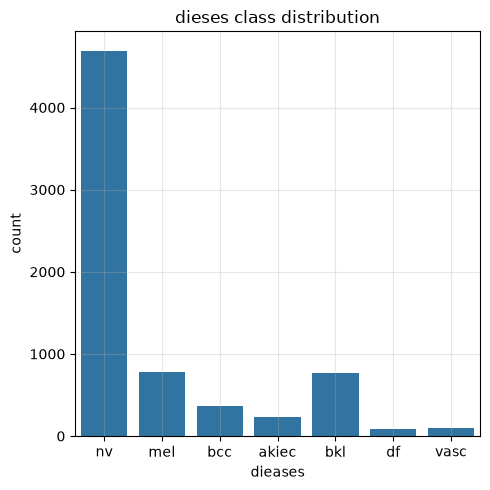

In [46]:
plt.figure(figsize=(5,5))
sns.countplot(data=df_tain,x='dx')
plt.grid(alpha=0.3)
plt.xlabel("dieases")
plt.ylabel("count")
plt.title("dieses class distribution")
plt.tight_layout()
plt.show()

In [ ]:
#pixel intensity analysis

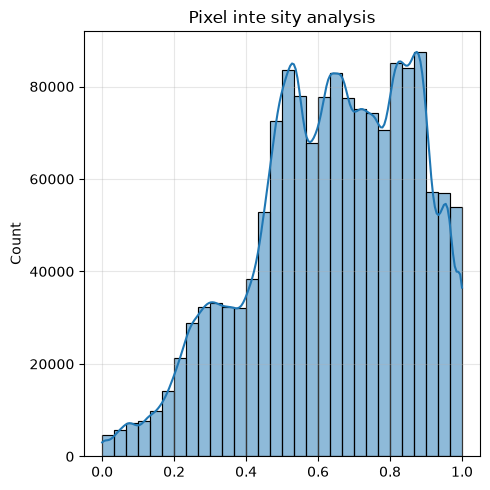

In [51]:
image , label = next(iter(train_dataset))

pixel_val = image[0:10].numpy().flatten()

plt.figure(figsize=(5,5))
sns.histplot(pixel_val,bins = 30,kde=True)
plt.title("Pixel inte sity analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

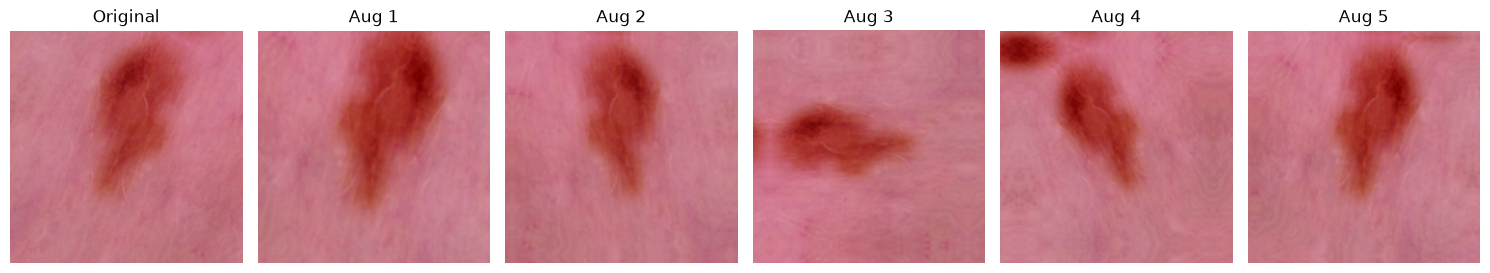

In [55]:
# Get one image from the training dataset
images, labels = next(iter(train_dataset))
image = images[0]

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

plt.figure(figsize=(15, 5))

plt.subplot(1, 6, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

for i in range(5):
    augmented = data_augmentation(image, training=True)

    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

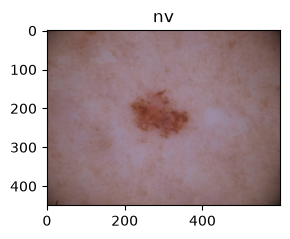

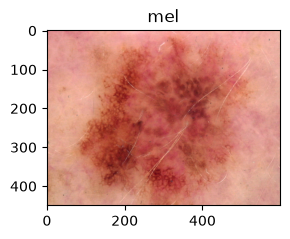

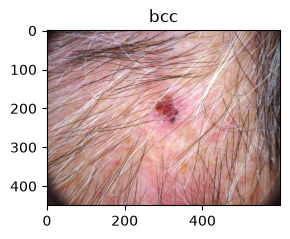

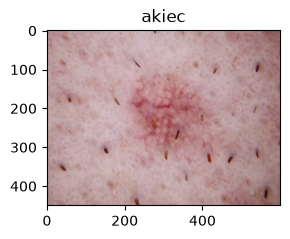

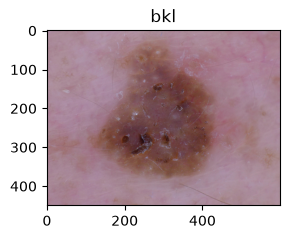

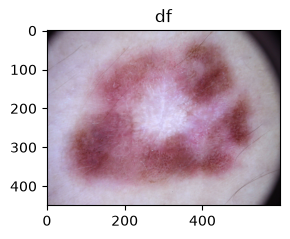

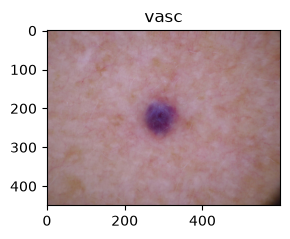

In [63]:
#class wise image charcteristic

dx= df_tain["dx"].unique()

for i in dx:
    row = df_tain[df_tain["dx"] == i]
    path = row["path"].iloc[0]
    image = cv2.imread(path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(3,3))
    plt.imshow(image_rgb)
    plt.title(i)
    plt.tight_layout()
    plt.show()

In [68]:
df_tain.to_csv(r"../data/selected_col/model_train.csv")
df_test.to_csv(r"../data/selected_col/model_test.csv")
df_val.to_csv(r"../data/selected_col/model_val.csv")